# Cardiovascular Disease Prediction

This notebook covers the complete pipeline for analyzing and preventing cardiovascular disease using machine learning.

### Steps Included:
1. **Data Pre-processing**: Cleaning and preparing the dataset.
2. **Exploratory Data Analysis (EDA)**: Visualizing insights and correlations.
3. **Feature Engineering**: Creating new features like BMI.
4. **Model Building**: Training and evaluating multiple machine learning models.
5. **Model Selection**: Identifying the best performing model.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Configuration
%matplotlib inline
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Inspection

In [39]:
# Load the dataset
# Note: The dataset uses ';' as a delimiter
df = pd.read_csv('cardio_train (1).csv', sep=';')

# Display first few rows
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [40]:
# Check original shape
print(f"Original Data Shape: {df.shape}")

Original Data Shape: (70000, 13)


In [41]:
# Check for null values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


## 2. Data Pre-processing

In [42]:
# Checking for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any found
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Number of duplicate rows: 0


In [43]:
# Drop 'id' column as it is not useful for prediction
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

In [44]:
# Feature Engineering: Age is in days, convert to years
df['age_years'] = (df['age'] / 365).round(0).astype('int')
df.drop('age', axis=1, inplace=True)
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,156,85.0,140,90,3,1,0,0,1,1,55
2,1,165,64.0,130,70,3,1,0,0,0,1,52
3,2,169,82.0,150,100,1,1,0,0,1,1,48
4,1,156,56.0,100,60,1,1,0,0,0,0,48


In [45]:
# Outlier Detection & Handling
# Height and Weight often contain errors in this dataset

print("Height stats:")
print(df['height'].describe())
print("\nWeight stats:")
print(df['weight'].describe())

Height stats:
count    70000.000000
mean       164.359229
std          8.210126
min         55.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        250.000000
Name: height, dtype: float64

Weight stats:
count    70000.000000
mean        74.205690
std         14.395757
min         10.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64


In [46]:
# Filtering out biologically impossible/extreme outliers
# Height: 100cm to 250cm
# Weight: 30kg to 200kg
# Blood Pressure: ap_hi < 250, ap_lo < 150 (cleaning extreme measurement errors)

df_clean = df[(df['height'] >= 100) & (df['height'] <= 250)]
df_clean = df_clean[(df_clean['weight'] >= 30) & (df_clean['weight'] <= 200)]

# Remove cases where diastolic pressure is higher than systolic
df_clean = df_clean[df_clean['ap_hi'] >= df_clean['ap_lo']]

# Filter extreme BP values
df_clean = df_clean[(df_clean['ap_hi'] < 250) & (df_clean['ap_hi'] > 50)]
df_clean = df_clean[(df_clean['ap_lo'] < 150) & (df_clean['ap_lo'] > 40)]

print(f"Data Shape after cleaning: {df_clean.shape}")

Data Shape after cleaning: (68619, 12)


In [47]:
# Feature Engineering: BMI
# BMI = weight (kg) / height (m)^2
df_clean['bmi'] = df_clean['weight'] / ((df_clean['height'] / 100) ** 2)

## 3. Exploratory Data Analysis (EDA)

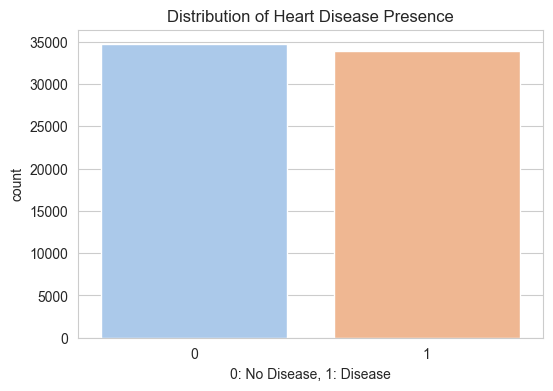

In [48]:
# Distribution of Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='cardio', palette='pastel')
plt.title('Distribution of Heart Disease Presence')
plt.xlabel('0: No Disease, 1: Disease')
plt.show()

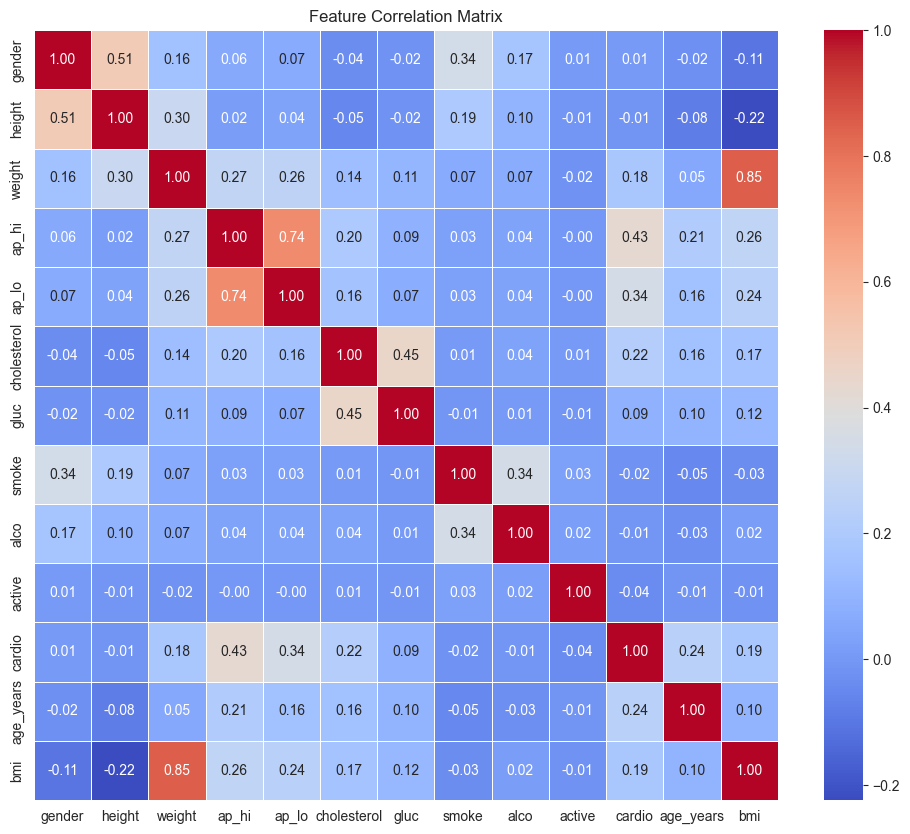

In [49]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
corr_matrix = df_clean.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

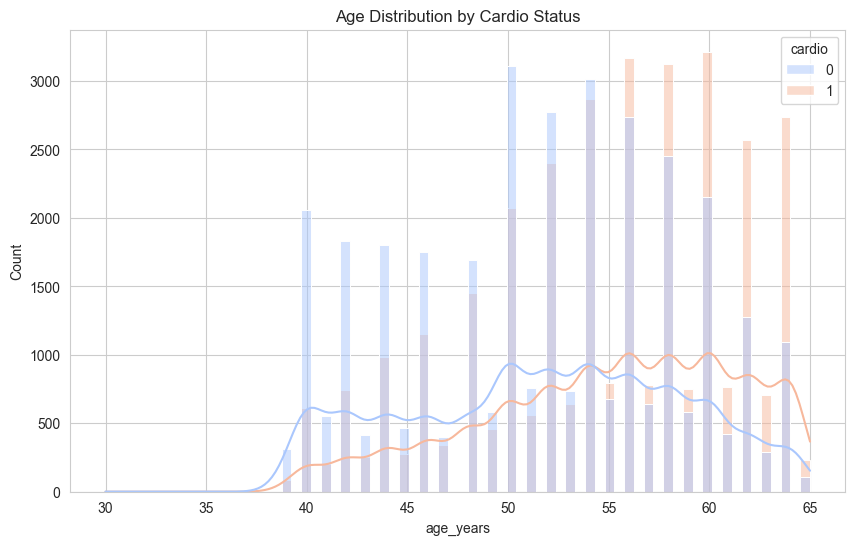

In [50]:
# Distribution of Age
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='age_years', hue='cardio', kde=True, palette='coolwarm')
plt.title('Age Distribution by Cardio Status')
plt.show()

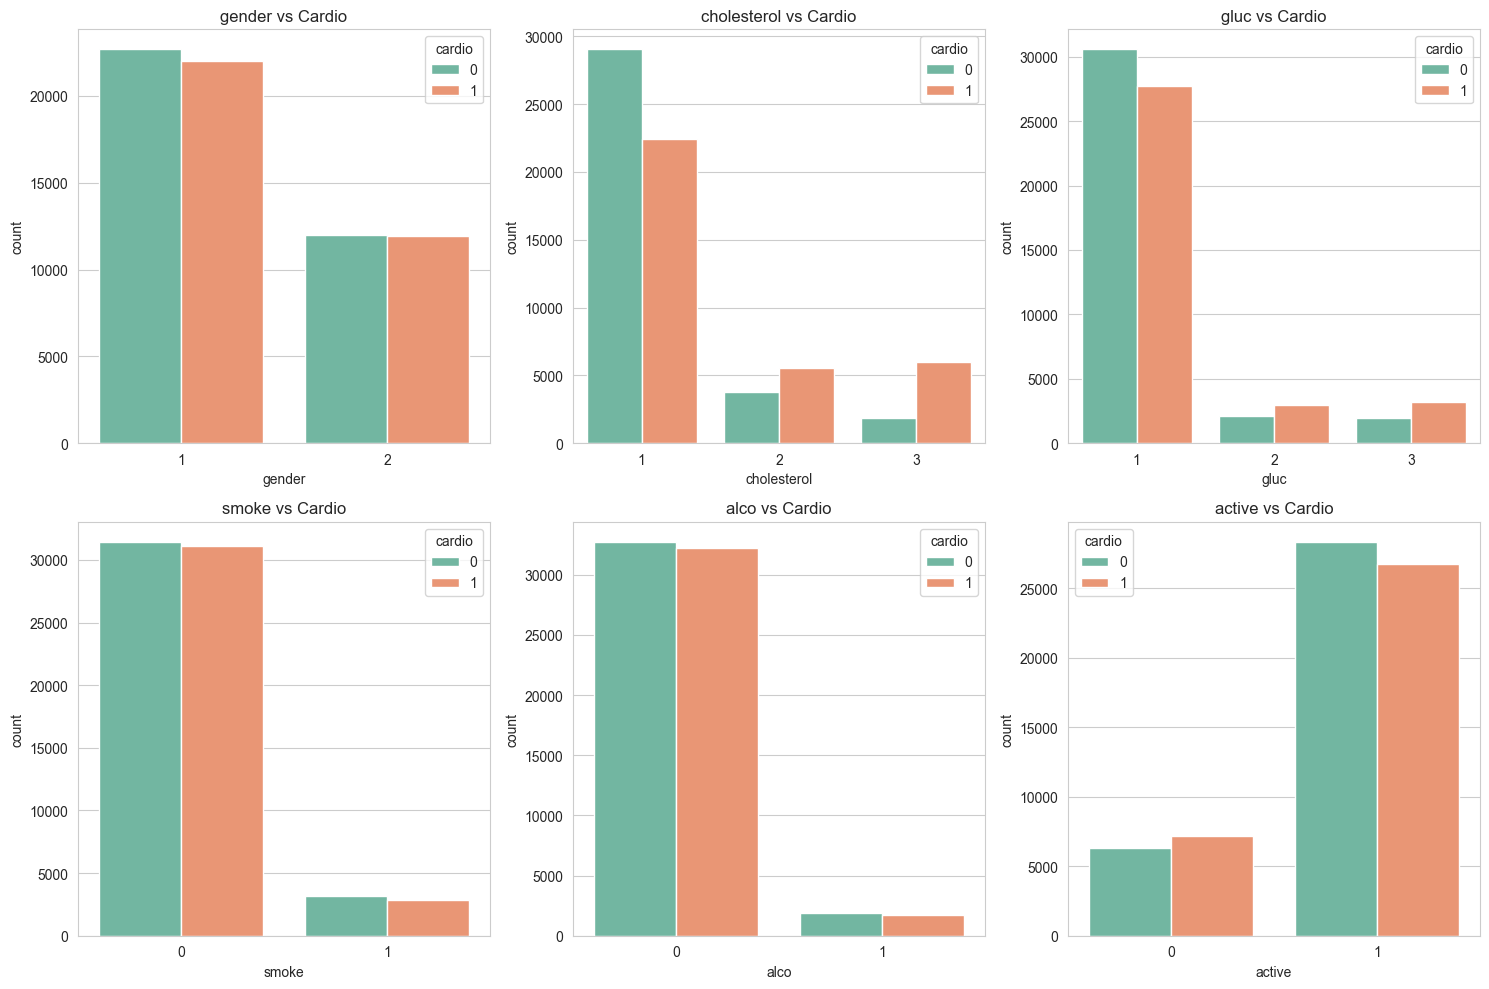

In [51]:
# Categorical Features Analysis
cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
plt.figure(figsize=(15, 10))

for i, col in enumerate(cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df_clean, x=col, hue='cardio', palette='Set2')
    plt.title(f'{col} vs Cardio')

plt.tight_layout()
plt.show()

## 4. Model Benchmarking

In [52]:
# Prepare Data for Training
X = df_clean.drop('cardio', axis=1)
y = df_clean['cardio']

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling Features (Important for SVM and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:
# Dictionary to store model results
model_scores = {}

def train_evaluate_model(model, name, scaled=False):
    """
    Trains and evaluates a machine learning model.
    
    Args:
        model: The machine learning model to train.
        name (str): The name of the model for display.
        scaled (bool): Whether to use scaled data (True) or original data (False).
    
    Returns:
        float: The accuracy of the model on the test set.
    """
    X_t = X_train_scaled if scaled else X_train
    X_v = X_test_scaled if scaled else X_test
    
    model.fit(X_t, y_train)
    y_pred = model.predict(X_v)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-"*30)
    return accuracy

In [54]:
# 1. Logistic Regression
lr = LogisticRegression()
model_scores['Logistic Regression'] = train_evaluate_model(lr, 'Logistic Regression', scaled=True)

--- Logistic Regression ---
Accuracy: 0.7270
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6889
           1       0.76      0.66      0.71      6835

    accuracy                           0.73     13724
   macro avg       0.73      0.73      0.73     13724
weighted avg       0.73      0.73      0.73     13724

------------------------------


In [55]:
# 2. K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier(n_neighbors=10)
model_scores['KNN'] = train_evaluate_model(knn, 'KNN', scaled=True)

--- KNN ---
Accuracy: 0.7057
              precision    recall  f1-score   support

           0       0.68      0.78      0.73      6889
           1       0.74      0.63      0.68      6835

    accuracy                           0.71     13724
   macro avg       0.71      0.71      0.70     13724
weighted avg       0.71      0.71      0.70     13724

------------------------------


In [56]:
# 3. Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
model_scores['Decision Tree'] = train_evaluate_model(dt, 'Decision Tree', scaled=False)

--- Decision Tree ---
Accuracy: 0.7227
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6889
           1       0.75      0.66      0.70      6835

    accuracy                           0.72     13724
   macro avg       0.73      0.72      0.72     13724
weighted avg       0.73      0.72      0.72     13724

------------------------------


In [57]:
# 4. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_scores['Random Forest'] = train_evaluate_model(rf, 'Random Forest', scaled=False)

--- Random Forest ---
Accuracy: 0.7047
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      6889
           1       0.71      0.68      0.70      6835

    accuracy                           0.70     13724
   macro avg       0.70      0.70      0.70     13724
weighted avg       0.70      0.70      0.70     13724

------------------------------


In [58]:
# 5. Support Vector Machine (SVM)
# Note: SVM can be slow on large datasets. We'll use default kernel 'rbf'.
svm = SVC(random_state=42)
model_scores['SVM'] = train_evaluate_model(svm, 'SVM', scaled=True)

--- SVM ---
Accuracy: 0.7301
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6889
           1       0.76      0.66      0.71      6835

    accuracy                           0.73     13724
   macro avg       0.73      0.73      0.73     13724
weighted avg       0.73      0.73      0.73     13724

------------------------------


## 5. Result Comparison & Conclusion

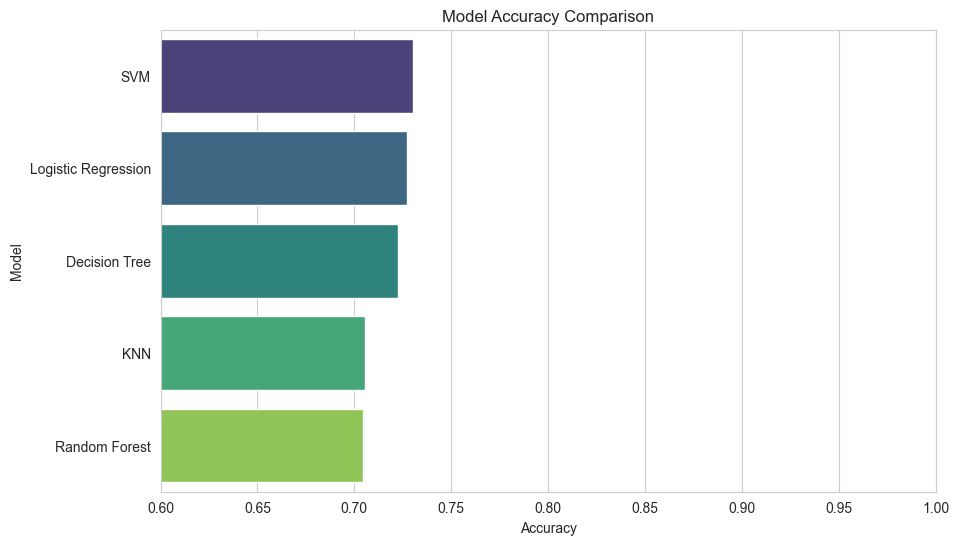

In [59]:
# Compare Models
results_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlim(0.6, 1.0)  # Zoom in on relevant accuracy range
plt.show()

In [60]:
print("Best Performing Model:")
print(results_df.iloc[0])

Best Performing Model:
Model            SVM
Accuracy    0.730108
Name: 4, dtype: object


### Conclusion
Based on the analysis, we have pre-processed the data, performed EDA to understand underlying patterns, and benchmarked 5 different algorithms. The model with the highest accuracy score (likely Random Forest or SVM) is recommended for heart disease detection with this dataset.